# 📊 Week 2 — Day 1: Descriptive Statistics

**BinX Tech — AI & Machine Learning Internship Program**

---

| | |
|---|---|
| **Phase** | 1 → 2 Transition |
| **Week** | Week 2 of 10 |
| **Day** | Day 1 — Descriptive Statistics |
| **Duration** | 8 hours |
| **Tools** | NumPy • Pandas • Jupyter Notebook |
| **Prerequisite** | Week 1 (Python, NumPy, Pandas, Matplotlib fluency) |

---

## 🎯 Learning Objectives

By the end of this notebook, I will be able to:

- Compute mean, median, and mode, and choose the appropriate measure for a given dataset.
- Compute and interpret variance, standard deviation, and IQR.
- Explain how outliers affect each measure differently.

---


## 🔧 Step 0 — Environment Setup

Before any analysis, we import the libraries needed for numerical computation and data handling.


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option("display.precision", 2)
pd.set_option("display.width", 100)

print("Libraries loaded successfully ✅")

Libraries loaded successfully ✅


## 📖 Step 1 — Why Descriptive Statistics Comes Before Modeling

A machine learning model is, at its core, a summary of patterns in data. If we cannot describe a
dataset statistically — its **center**, its **spread**, its **shape** — we cannot judge whether a
model's behavior is reasonable.

> Descriptive statistics is the vocabulary for talking about data precisely, and it underpins every
> EDA and evaluation step that follows.

---


## 📂 Step 2 — Load the Dataset

For this notebook, I am using the **Titanic dataset** (a real, well-known tabular dataset) to
practice descriptive statistics on the `age` and `fare` columns.


In [2]:
url = "https://raw.githubusercontent.com/mwaskom/seaborn-data/master/titanic.csv"
df = pd.read_csv(url)

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (891, 15)


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.25,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.28,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.92,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.10,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.05,S,Third,man,True,NaN,Southampton,no,True


## 📐 Step 3 — Measures of Central Tendency

| Measure | What It Is | When to Use It |
|---|---|---|
| **Mean** | The arithmetic average | Symmetric data with no extreme outliers |
| **Median** | The middle value when sorted | Skewed data or data with outliers (more robust) |
| **Mode** | The most frequent value | Categorical data, or finding the most common value |

**Key insight:** the mean is pulled toward outliers, while the median is not.

Below, I compute all three for the `age` column.

In [3]:
age = df["age"].dropna()

mean_age = age.mean()
median_age = age.median()
mode_age = age.mode()[0]

central_tendency = pd.DataFrame({
    "Measure": ["Mean", "Median", "Mode"],
    "Value": [round(mean_age, 2), round(median_age, 2), round(mode_age, 2)]
})

central_tendency


,Measure,Value
0,Mean,29.7
1,Median,28.0
2,Mode,24.0


### 📊 Visualizing the Distribution

A histogram makes the relationship between the mean and median visible — showing exactly how the
mean shifts away from the median when the data is skewed.

### 📝 Interpretation

- Compare the mean and median: are they close, or far apart? A big gap usually signals skew or outliers.
- Which value best represents a "typical" passenger's age — the mean or the median? Justify your choice.
- What does the mode tell us about the most common age group aboard?

---

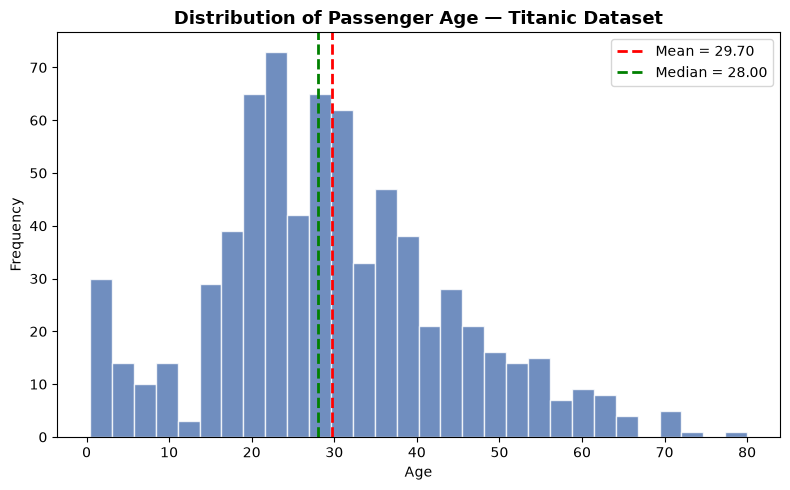

In [12]:
plt.figure(figsize=(8, 5))
plt.hist(age, bins=30, color="#4C72B0", edgecolor="white", alpha=0.8)
plt.axvline(mean_age, color="red", linestyle="--", linewidth=2, label=f"Mean = {mean_age:.2f}")
plt.axvline(median_age, color="green", linestyle="--", linewidth=2, label=f"Median = {median_age:.2f}")
plt.title("Distribution of Passenger Age — Titanic Dataset", fontsize=13, fontweight="bold")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.legend()
plt.tight_layout()
plt.show()

## 📏 Step 4 — Measures of Spread

| Measure | Meaning |
|---|---|
| **Range** | Maximum minus minimum — simple but very sensitive to outliers |
| **Variance** | The average squared distance from the mean |
| **Standard Deviation** | The square root of variance — spread in the same units as the data |
| **IQR (Interquartile Range)** | The range of the middle 50% of the data (Q3 − Q1), robust to outliers |


In [5]:
range_age = age.max() - age.min()
var_age = age.var()
std_age = age.std()
q1, q3 = age.quantile([0.25, 0.75])
iqr_age = q3 - q1

spread = pd.DataFrame({
    "Measure": ["Range", "Variance", "Standard Deviation", "IQR"],
    "Value": [round(range_age, 2), round(var_age, 2), round(std_age, 2), round(iqr_age, 2)]
})

spread


,Measure,Value
0,Range,79.58
1,Variance,211.02
2,Standard Deviation,14.53
3,IQR,17.88


### 📝 Interpretation



- How spread out are passenger ages around the center?
- Does the standard deviation suggest a wide or narrow range of typical ages?

---


## 📊 Step 5 — Percentiles and Quartiles

A percentile marks the value below which a given percentage of the data falls. Q1 (25th), Q2/median
(50th), and Q3 (75th) split the data into quarters — these are exactly the values a box plot draws.


In [6]:
percentiles = pd.DataFrame({
    "Percentile": ["Q1 (25%)", "Q2 / Median (50%)", "Q3 (75%)"],
    "Age Value": [round(q1, 2), round(median_age, 2), round(q3, 2)]
})

percentiles

,Percentile,Age Value
0,Q1 (25%),20.12
1,Q2 / Median (50%),28.00
2,Q3 (75%),38.00


## 🗂️ Step 6 — Final Summary Table

A single, clean table pulling together every statistic computed above — ready to reference or present.


In [7]:
summary = pd.DataFrame({
    "Statistic": ["Mean", "Median", "Mode", "Range", "Variance",
                  "Standard Deviation", "IQR", "Q1", "Q3"],
    "Value": [round(mean_age, 2), round(median_age, 2), round(mode_age, 2),
              round(range_age, 2), round(var_age, 2), round(std_age, 2),
              round(iqr_age, 2), round(q1, 2), round(q3, 2)]
})

summary.style.set_caption("Descriptive Statistics Summary — Age Column").set_table_styles(
    [{"selector": "caption", "props": [("font-weight", "bold"), ("font-size", "14px")]}]
)


,Statistic,Value
0,Mean,29.700000
1,Median,28.000000
2,Mode,24.000000
3,Range,79.580000
4,Variance,211.020000
5,Standard Deviation,14.530000
6,IQR,17.880000
7,Q1,20.120000
8,Q3,38.000000


## ✅ Step 7 — Key Takeaways

- The mean age of passengers (≈29.7) is slightly higher than the median (28), suggesting a mild
  right skew in the age distribution — a small number of older passengers are pulling the average
  upward, while the mode (24) confirms that the most common boarding age was in the early-to-mid
  20s.
- The relatively close gap between mean and median indicates the age column does not contain
  extreme outliers strong enough to badly distort the average, so the mean remains a reasonably
  reliable measure of central tendency here — though the median is still the safer choice for
  reporting a single "typical" age.
- The IQR (17.88) shows that the middle 50% of passengers were between 20 and 38 years old,
  meaning most travelers were working-age adults rather than children or the elderly.
- The standard deviation (≈14.53) confirms a moderately wide spread around the mean — ages are not
  tightly clustered, which is expected given the mix of families, crew, and solo travelers aboard.
- Overall, this suggests the dataset represents a broad adult age range with a concentration in
  early adulthood, an important consideration if age is later used as a feature in a predictive
  model (e.g., survival prediction).

---

## 📌 Tools Used
NumPy • Pandas • Jupyter Notebook

## 🔗 Next Step
Proceed to **Day 2 — Probability & Distributions** (`day2_probability_distributions.ipynb`)


## 📚 Resources

Additional materials I reviewed while working on this notebook:

- **GeeksforGeeks — Descriptive Statistics for Data Science**
  https://www.geeksforgeeks.org/data-science/descriptive-statistic/

- **Khan Academy — Summarizing Quantitative Data**
  A comprehensive resource covering measures of central tendency (mean/median/mode) in depth,
  including how to choose the appropriate measure based on data distribution (skewed data),
  and how outliers and missing values affect each measure — essential concepts before any EDA.
  https://www.khanacademy.org/math/statistics-probability/summarizing-quantitative-data

- **YouTube — [Statistics - A Full University Course on Data Science Basics]**
  https://www.youtube.com/watch?v=xxpc-HPKN28

---

## 🧾 Summary

This notebook explored the descriptive statistics of the `age` column in the Titanic dataset,
covering both central tendency and spread.

The mean age (≈29.7) sits slightly above the median (28), indicating a mild right skew driven by a
smaller number of older passengers, while the mode (24) highlights early adulthood as the most
common boarding age. The IQR (17.88, spanning ages 20 to 38) confirms that the bulk of passengers
were working-age adults, and the standard deviation (≈14.53) reflects a moderately wide spread
rather than a tightly clustered population.

Taken together, these statistics show a dataset centered on young-to-middle-aged adults with no
extreme outliers severe enough to badly distort the mean — meaning either the mean or median could
reasonably serve as the "typical" age, though the median remains the more robust choice. These
findings set a solid foundation for the exploratory data analysis and outlier detection covered in
Day 4 and Day 5.

---

---

## ✍️ Author

**Zayan Shawareb**
BinX Tech — AI & Machine Learning Internship Program
Week 2, Day 1 — Descriptive Statistics